In [1]:
import numpy as np
import math
from scipy.constants import m_e, c, e, hbar, physical_constants, epsilon_0, k
from scipy.special import gamma
from scipy import integrate
from scipy.interpolate import interp1d
import tqdm
import numba
import matplotlib.pyplot as plt
import pandas as pd
import pdb  # or import ipdb

/var/folders/kq/4wb4bwzd1d381_jymps9w97c0000gn/T/ipykernel_67858/1376656219.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Temperature from ionization

In [2]:
Uion = 13.6*e  # ionization energy in Joules, for Hydrogen

# Calculate the ADK prefactors (See Chen, JCP 236 (2013), equation (2))
# - Scalars
alpha = physical_constants['fine-structure constant'][0]
r_e = physical_constants['classical electron radius'][0]
wa = alpha**3 * c / r_e
Ea = m_e*c**2/e * alpha**4/r_e
# - Arrays (one element per ionization level)
UH = 13.6*e
Z = 1
n_eff = Z * np.sqrt( UH/Uion )
l_eff = n_eff - 1
C2 = 2**(2*n_eff) / (n_eff * gamma(n_eff+l_eff+1) * gamma(n_eff-l_eff))
# For now, we assume l=0, m=0
adk_power = - (2*n_eff - 1)
adk_prefactor = wa * C2 * ( Uion/(2*UH) ) \
    * ( 2*(Uion/UH)**(3./2)*Ea )**(2*n_eff - 1)
adk_exp_prefactor = -2./3 * ( Uion/UH )**(3./2) * Ea

In [3]:
@numba.njit
def get_ib_heating_rate( a, n0, kin_energy, ioniz_frac, lambd ):

    # Compute thermal velocity
    kin_energy_per_electron = kin_energy/ioniz_frac
    vth_over_c = math.sqrt( kin_energy_per_electron/(3/2*m_e*c**2) )
    
    # Compute Coulomb log
    vbar_over_c = math.sqrt( vth_over_c**2 + a**2/6 ) # Eq. 4.56 in Pierre Michel's book
    bmin = 0.5*hbar/(m_e*c*vbar_over_c) # Eq. 4.58 in Pierre Michel's book
    bmax = vbar_over_c * lambd/(2*math.pi) # Eq. 4.59 in Pierre Michel's book
    bperp = r_e / vbar_over_c**2 # Eq. 4.60 in Pierre Michel's book
    C_log = 0.5*np.log( (1 + (bmax/bperp)**2 )/(1 + (bmin/bperp)**2) )

    # Compute heating rate
    n_i = n0*ioniz_frac
    if ( vth_over_c > a ):
        nu_ei = 4*(2*np.pi)**.5/3 * (n_i * r_e**2 * c) * C_log/vth_over_c**3 # Eq. 4.21 in Pierre Michel's book
    else:
        nu_ei = 16 * (n_i * r_e**2 * c) * C_log / a**3 * np.log( 2**.5 * a/vth_over_c ) # Eq. 4.36 in Pierre Michel's book

    heating_per_electron =  0.5 * m_e*c**2 * a**2 * nu_ei
    return heating_per_electron


@numba.njit
def get_fraction_and_temperature( a0, tau, lambd, ell, npts_per_wavelength=80, 
        compute_inverse_bremsstrahlung=False, n0=1.25e24, npts_per_tau_ib=80 ):
    """
    a0: Peak laser amplitude
    tau: laser duration
    lambd: laser wavelength
    ell: polarization vector
    n0: electron density if the plasma was fully ionized
    """
    # Precompute a few things
    omega = 2*np.pi*c/lambd
    E0 = m_e*omega*c/e
    inv_tau2 = 1./tau**2
    # Check the ellipticity
    assert len(ell) == 2
    assert abs(ell[0]**2 + ell[1]**2 - 1) < 1.e-10 # Check that the ellipticity is normalized

    t = -3*tau # Start at 3 sigma
    ioniz_frac = 0
    kin_energy = 0

    if compute_inverse_bremsstrahlung:
        assert n0 > 0
        assert (ell[1] < 1.e-10) or (ell[0] < 1.e-10) # Only works for linear polarization

    # Loop for ADK: small timestep
    dt = lambd/c/npts_per_wavelength
    while ((ioniz_frac < 0.999) and (t < 3*tau)):

        # Get the electric field and vector potential
        a_env = a0 * math.exp(-inv_tau2*t**2)
        a = a_env * math.sqrt( ell[0]**2*np.cos(omega*t)**2 + ell[1]**2*np.sin(omega*t)**2 )
        E = E0 * a_env * math.sqrt( ell[0]**2*np.sin(omega*t)**2 + ell[1]**2*np.cos(omega*t)**2 )                           

        # Get the ionization rate
        w = 0
        if E > 0:
            w = adk_prefactor * E**adk_power * math.exp( adk_exp_prefactor/E )
        dp = 1 - math.exp( -w*dt )

        # increment the ionization fraction
        kin_energy += (1 - ioniz_frac)*dp * m_e*c**2 * (math.sqrt( 1 + a**2 ) - 1)
        ioniz_frac += (1 - ioniz_frac)*dp

        if compute_inverse_bremsstrahlung and (ioniz_frac>0):
            kin_energy += dt * ioniz_frac * get_ib_heating_rate( a_env, n0, kin_energy, ioniz_frac, lambd )

        t += dt

    # Once the plasma is fully ionized we can take much larger timesteps to compute IB
    if compute_inverse_bremsstrahlung:
        dt = tau/npts_per_tau_ib        
        while (t < 3*tau):
            a_env = a0 * math.exp(-inv_tau2*t**2)
            kin_energy += dt * ioniz_frac * get_ib_heating_rate( a_env, n0, kin_energy, ioniz_frac, lambd )
            t += dt

    T = 0.
    if ioniz_frac > 0:
        T = kin_energy/(3/2*ioniz_frac*e)

    return ioniz_frac, T, t

7.920210490438286e+17
-55.46666666666667


/var/folders/kq/4wb4bwzd1d381_jymps9w97c0000gn/T/ipykernel_67858/4228994689.py:10: RuntimeWarning: invalid value encountered in sqrt
  a0 = e * lambd/(np.pi * m_e * c) * np.sqrt(central_slice/(2 * epsilon_0 * c**3))


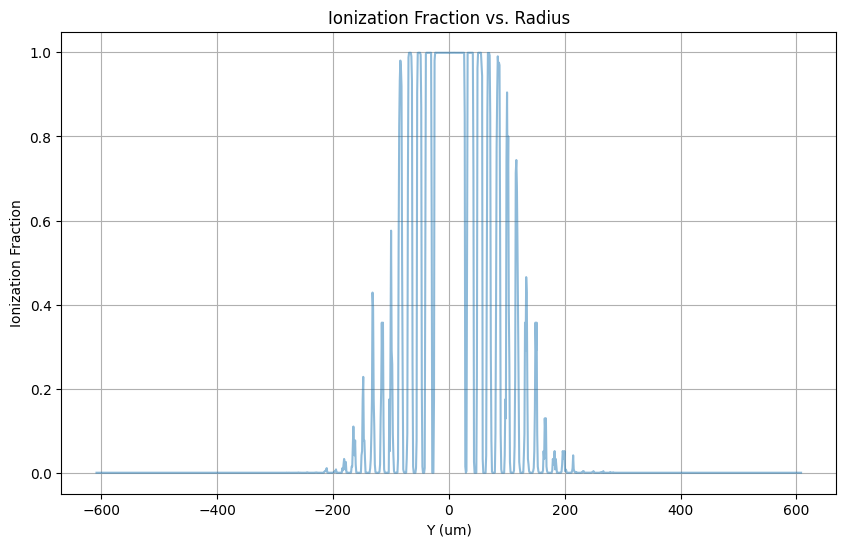

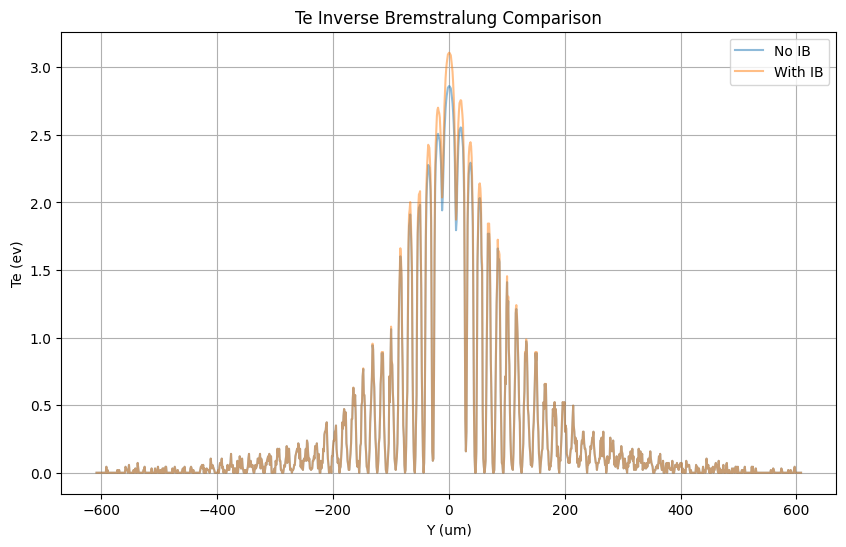

In [4]:
intensity_data = pd.read_csv('/Users/cmccombs/WarpxFiles/axicon_intensity/Iyz_wm2.csv', header=None)
y = pd.read_csv('/Users/cmccombs/WarpxFiles/axicon_intensity/y.csv', header=None)
x= np.linspace(-6.08e02, 6.08e02, 1936)
central_slice = intensity_data.values[:, intensity_data.shape[1] // 2]
average = sum(central_slice[0:30])/len(central_slice[0:30])
print(np.min(central_slice))
central_slice = central_slice - average
print(sum(central_slice[0:30])/len(central_slice[0:30]))
lambd = 0.8e-6
a0 = e * lambd/(np.pi * m_e * c) * np.sqrt(central_slice/(2 * epsilon_0 * c**3))

tau = 30e-15
Te=np.zeros_like(a0)
Ionfrac = np.zeros_like(a0)
Te2=np.zeros_like(a0)
Ionfrac2 = np.zeros_like(a0)
ell = np.array([0,1]) 
for i in range(len(a0)):
    ioniz_frac, T, _ = get_fraction_and_temperature(a0[i], tau, lambd, ell)
    Te[i] = T
    Ionfrac[i] = ioniz_frac
for i in range(len(a0)):
    ioniz_frac, T, _ = get_fraction_and_temperature(a0[i], tau, lambd, ell, compute_inverse_bremsstrahlung=True)
    Te2[i] = T
    Ionfrac2[i] = ioniz_frac
# Plot adjustments
plt.figure(figsize=(10, 6))  # Larger figure size
plt.plot(y, Ionfrac2, alpha=0.5)  # Smaller points with some transparency
plt.title('Ionization Fraction vs. Radius')  # Title
plt.xlabel('Y (um)')  # X-axis label
plt.ylabel('Ionization Fraction')  # Y-axis label
plt.grid(True)  # Add gridlines

plt.show()

plt.figure(figsize=(10, 6))  # Larger figure size
plt.plot(y, Te, alpha=0.5, label='No IB')  # Smaller points with some transparency and label
plt.plot(y, Te2, alpha=0.5, label='With IB')
plt.title('Te Inverse Bremstralung Comparison') 
plt.xlabel('Y (um)')  # X-axis label
plt.ylabel('Te (ev)')  # Y-axis label
plt.legend()  # Display the legend
plt.grid(True)  # Add gridlines
plt.show()

In [5]:
n0 = 1.25e24
r0i = len(y) // 2

r_values = np.array(y[r0i:-1])
r_values = r_values[:, 0]
r_min = r_values[0] * 1e-6
r_max = r_values[-1] * 1e-6
print(r_min)
alpha_values = np.array(Ionfrac[r0i:-1])
Te_values = np.array(Te[r0i:-1]) * 11604.51812 #kelvin

# Interpolating functions
alpha_interp = interp1d(r_values * 1e-6, alpha_values, kind='cubic')
Te_interp = interp1d(r_values * 1e-6, Te_values, kind='cubic')

# Function to integrate
def integrand(r):
    return n0 * alpha_interp(r) * 1.5 * k * Te_interp(r) * 2 * np.pi * r

# Numerical Integration
integral_value, error = integrate.quad(integrand, r_min, r_max)
print(f"Deposited energy: {integral_value} Joules/meter")

5.004115226338399e-07
Deposited energy: 0.010352810980645097 Joules/meter


/var/folders/kq/4wb4bwzd1d381_jymps9w97c0000gn/T/ipykernel_67858/2569148960.py:21: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_value, error = integrate.quad(integrand, r_min, r_max)


Text(0, 0.5, 'Temperature (eV)')

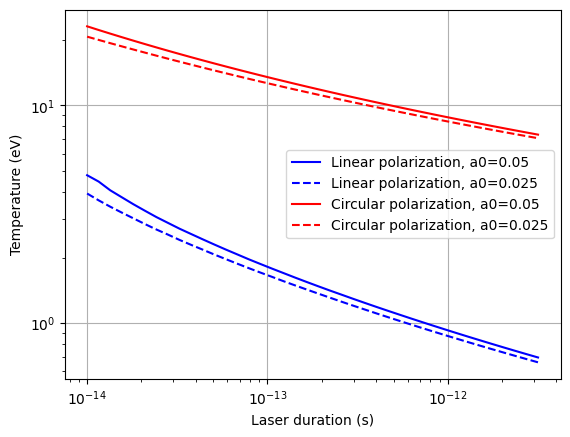

In [58]:
tau_arr = 10**np.linspace(-14, -11.5, 40)

a0 = 0.05
ell = np.array([0,1]) 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b-', label='Linear polarization, a0=0.05' )

a0 = 0.025
ell = np.array([0,1]) 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b--', label='Linear polarization, a0=0.025' )

a0 = 0.05
ell = np.array([1,1])/2**.5 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r-', label='Circular polarization, a0=0.05' )

a0 = 0.025
ell = np.array([1,1])/2**.5 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r--', label='Circular polarization, a0=0.025' )

plt.grid()
plt.legend(loc=0)

plt.xlabel('Laser duration (s)')
plt.ylabel('Temperature (eV)')

# Ionization volume for a focusing pulse

In [123]:
#a0 = e * lambd/(np.pi * m_e * c) * np.sqrt(central_slice/(2 * epsilon_0 * c**3))
a0=0.05
w0 = 5.e-6
lambd = 0.8e-6
tau = 1.5e-12
ell = np.array([0,1]) 

zr = np.pi*w0**2/lambd

In [124]:
zmax = 400e-6
rmax = 50e-6
r, z = np.meshgrid( np.linspace(-rmax, rmax, 100), np.linspace(-zmax, zmax, 100), indexing='ij' )
a = a0/np.sqrt(1 + z**2/zr**2)*np.exp( -r**2/w0**2/(1+z**2/zr**2) )

n = np.zeros_like( a )
T = np.zeros_like( a )
for i in tqdm.tqdm( range(n.shape[0]) ):
    for j in range(n.shape[1]):
        ion, T0, _ = get_fraction_and_temperature( a[i,j], tau, lambd, ell, compute_inverse_bremsstrahlung=True, n0=2e24 )
        n[i,j] = ion
        T[i,j] = T0

100%|█████████████████████████████████████████| 100/100 [01:07<00:00,  1.48it/s]


Text(0, 0.5, 'r (microns)')

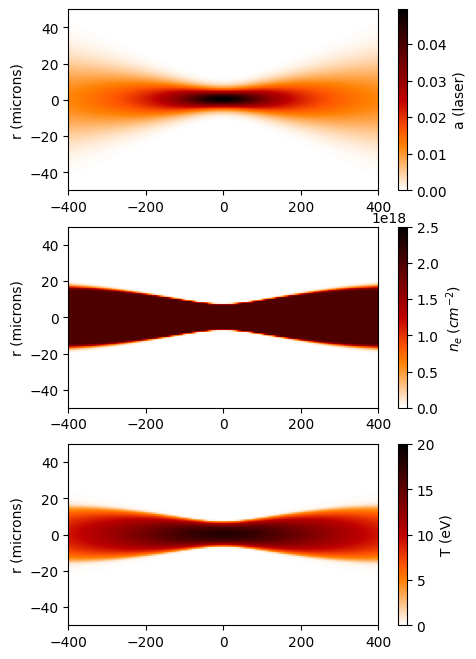

In [125]:
plt.figure(figsize=(5,8))

extent = 1.e6*np.array([-zmax, zmax, -rmax, rmax])

plt.subplot(311)
plt.imshow(a, extent=extent, aspect='auto', cmap='gist_heat_r')
cb = plt.colorbar()
cb.set_label('a (laser)')
plt.ylabel('r (microns)')

plt.subplot(312)
plt.imshow(2e18*n, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=2.5e18)
cb = plt.colorbar()
cb.set_label('$n_e\;(cm^{-2})$')
plt.ylabel('r (microns)')

plt.subplot(313)
plt.imshow(T, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=20)
cb = plt.colorbar()
cb.set_label('T (eV)')
plt.ylabel('r (microns)')

# Inverse Bremstrahlung details

Text(0, 0.5, 'Heating rate per\n electron ($eV.ps^{-1}$)')

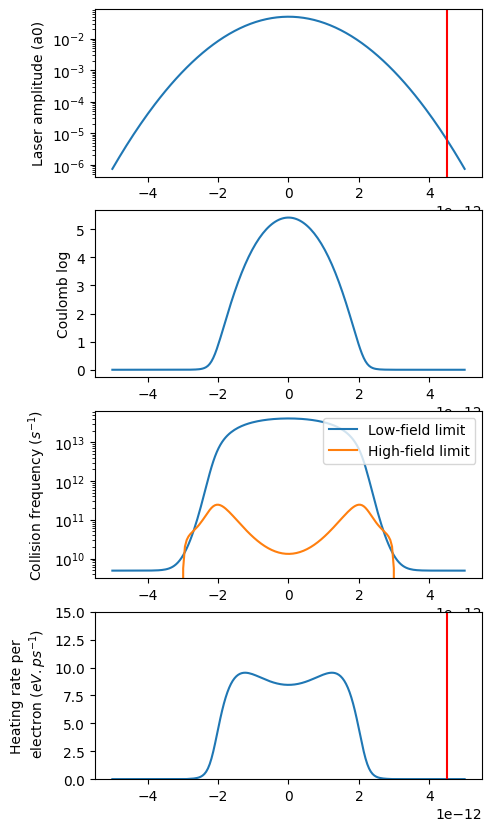

In [120]:
n0 = 2e24
a0 = 0.05
lambd = 0.8e-6
tau = 1.5e-12
ell = np.array([0,1]) 

ioniz_frac, T_eV, t0 = get_fraction_and_temperature(a0, tau, lambd, ell)

t_arr = np.linspace(-5e-12, 5e-12, 200)
a_arr = a0*np.exp(-t_arr**2/tau**2)

# Compute Coulomb log
vth_over_c = math.sqrt( T_eV*e/(m_e*c**2) ) # no additional factor of 1/3 here
vbar_over_c = np.sqrt( vth_over_c**2 + a_arr**2/6 ) # Eq. 4.56 in Pierre Michel's book
bmin = 0.5*hbar/(m_e*c*vbar_over_c) # Eq. 4.58 in Pierre Michel's book
bmax = vbar_over_c * lambd/(2*np.pi) # Eq. 4.59 in Pierre Michel's book
bperp = r_e / vbar_over_c**2 # Eq. 4.60 in Pierre Michel's book
C_log = 0.5*np.log( (1 + (bmax/bperp)**2 )/(1 + (bmin/bperp)**2) )

n_i = n0*ioniz_frac
nu_ei_lf = 4*(2*np.pi)**.5/3 * (n_i * r_e**2 * c) * C_log/vth_over_c**3 # Eq. 4.21 in Pierre Michel's book
nu_ei_hf = 16 * (n_i * r_e**2 * c) * C_log / a_arr**3 * np.log( 2**.5 * a_arr/vth_over_c )
nu_ei_hf = nu_ei_hf * (nu_ei_hf > 0)

heating_per_electron_lf = 0.5 * m_e*c**2 * a_arr**2 * nu_ei_lf
heating_per_electron_hf = 0.5 * m_e*c**2 * a_arr**2 * nu_ei_hf
heating_per_electron = np.where( vth_over_c < a_arr, heating_per_electron_hf, heating_per_electron_lf )

plt.figure(figsize=(5,10))

plt.subplot(411)
plt.semilogy( t_arr, a_arr )
plt.axvline( x=t0, color='r' )
plt.ylabel('Laser amplitude (a0)')

plt.subplot(412)
plt.plot( t_arr, C_log )
plt.ylabel('Coulomb log')

plt.subplot(413)
plt.semilogy( t_arr, nu_ei_lf, label='Low-field limit' )
plt.semilogy( t_arr, nu_ei_hf, label='High-field limit' )
plt.legend(loc=0)
plt.ylabel('Collision frequency ($s^{-1}$)')

plt.subplot(414)
#plt.plot( t_arr, heating_per_electron_lf*1e-12/e, label='Low-field limit' )
#plt.plot( t_arr, heating_per_electron_hf*1e-12/e, label='High-field limit' )
plt.plot( t_arr, heating_per_electron*1e-12/e )
plt.axvline( x=t0, color='r' )
plt.ylim(0, 15)
plt.ylabel('Heating rate per\n electron ($eV.ps^{-1}$)')

In [ ]:
dt = t_arr[1] - t_arr[0]
energy_per_electron = (heating_per_electron * (t_arr>t0)).sum() * dt
T_ib_eV = energy_per_electron/(3/2*e)

In [ ]:
T_ib_eV

In [ ]:
_, T_ib_eV2, _ = get_fraction_and_temperature(a0, tau, lambd, ell, compute_inverse_bremsstrahlung=True, n0=n0)
print( T_ib_eV2 )